# Homework 2

# Part 2: Numerical

Lotka-Volterra predator-prey model:

\begin{align}

&\frac{dx}{dt} = \alpha x - \beta xy, \\

&\frac{dy}{dt} = \delta xy - \gamma y,

\end{align}

where $x$ - population of hare (in thousands), $y$ - population of lunx (in thousands), and $\alpha, \beta, \gamma, \delta > 0$.

# 2.1 Synthetic Data 

# a) Generate data 

\begin{align}

&\alpha = 0.6, \beta = 0.025, \delta = 0.0125, \gamma = 0.5 \\

& x(0) = 30, y(0) = 4

\end{align}


System simulated for $t = 0,1,...,90$.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp 
import matplotlib.pyplot as plt 
import torch as tc
import torch.nn as nn

Running code on GPU (CUDA or MPS - for MacOS)

In [5]:
#Check for using GPU on MacOS (No CUDA for MacOS)
print(tc.backends.mps.is_available())
device = tc.device("mps" if tc.backends.mps.is_available() else "cpu")

#For using CUDA, e.g., on Symmetry, comment the above and run the below instead
#device = 'cuda' if tc.cuda.is_available() else 'cpu'

True


Solve the system of differenatil equations and plot the results

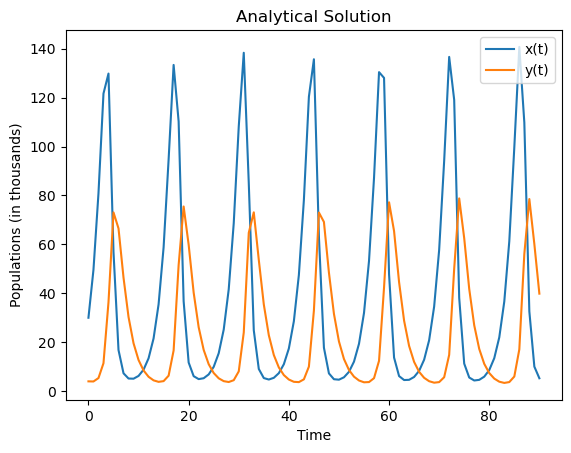

In [7]:
#Solving the system of differential equations

#Parameters
a = 0.6
b = 0.025
d = 0.0125
g = 0.5

#Initail conditions
x0 = 30
y0 = 4

#Time points to evaluate
t_eval = np.linspace(0, 90, 91)
t_span = (0,90)

#Define system of first order differential equations
def populations_ODEs(t, v):
    """
    t - time array 
    v = (x,y) - vector of x and y values
    """
    x, y = v

    dxdt = a*x - b*x*y
    dydt = d*x*y - g*y

    return [dxdt, dydt]

#Solving
sol = solve_ivp(populations_ODEs, t_span, [x0, y0], t_eval=t_eval)

#Accessing the data for later use
t_tc=tc.from_numpy(sol.t).unsqueeze(1).float()
x_tc=tc.from_numpy(sol.y[0]).unsqueeze(1).float()
y_tc=tc.from_numpy(sol.y[1]).unsqueeze(1).float()

#Accesing the data for plot 
x_data = sol.y[0]
y_data = sol.y[1]


# Plot
fig, ax = plt.subplots()
ax.plot(t_eval, x_data, label="x(t)")
ax.plot(t_eval, y_data, label="y(t)")

ax.set_title("Analytical Solution")
ax.set_xlabel("Time")
ax.set_ylabel("Populations (in thousands)")
ax.legend()

fig.savefig("analytical_solution.png")
plt.show()


# b) Approximate time derivatives using central differences

\begin{align}

&\dot{x}(t_i) \approx \frac{x_{i+1}-x_{i-1}}{2\Delta t}\\

&\dot{y}(t_i) \approx \frac{y_{i+1}-y_{i-1}}{2\Delta t}\\

\end{align}

In [14]:
#Approximating derivatives

dx_approx = np.zeros(len(t_eval))
dy_approx = np.zeros(len(t_eval))

for k in range(len(t_eval)):
    if k != 0 and k < (len(t_eval) -1):
        dx_approx[k] = (x_data[k+1] - x_data[k-1])/2
        dy_approx[k] = (y_data[k+1] - y_data[k-1])/2

#First value repeated 
dx_approx[0] = dx_approx[1]
dy_approx[0] = dy_approx[1]

#Last value repeated
dx_approx[-1] = dx_approx[-2]
dy_approx[-1] = dy_approx[-2]

#Check
print(dx_approx)
print(dy_approx)

[ 2.54117469e+01  2.54117469e+01  3.60272108e+01  2.44923142e+01
 -3.23754854e+01 -5.65037726e+01 -2.48021598e+01 -5.82284004e+00
 -1.10309717e+00  5.32266631e-01  1.84006829e+00  3.60445183e+00
  6.39582248e+00  1.10352775e+01  1.86076029e+01  2.95879817e+01
  3.72863895e+01  7.78344392e+00 -4.82993668e+01 -4.92695621e+01
 -1.53164973e+01 -3.39357399e+00 -4.18253068e-01  9.58923850e-01
  2.32443572e+00  4.32835203e+00  7.61870982e+00  1.30828994e+01
  2.17489213e+01  3.32621094e+01  3.48275292e+01 -1.15583919e+01
 -5.67188812e+01 -3.80021207e+01 -9.76746013e+00 -2.15733106e+00
  5.04490409e-02  1.30046874e+00  2.77391256e+00  5.04318037e+00
  8.79393640e+00  1.50308433e+01  2.47815505e+01  3.64209452e+01
  2.87618218e+01 -2.85771703e+01 -5.89591659e+01 -2.79662742e+01
 -6.44141929e+00 -1.28379506e+00  3.95826782e-01  1.60312734e+00
  3.19617322e+00  5.73384000e+00  9.95706099e+00  1.69353835e+01
  2.76034788e+01  3.85883653e+01  2.04396623e+01 -4.12921182e+01
 -5.71659001e+01 -2.08317

# c) Estimating the parameters using linear regression